# Chapter 03 Probability And Distributions: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-03-probability-and-distributions-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for Chapter 3: Probability and Distributions.

Same pattern as prior chapters: each function builds one self-contained, standalone Plotly
HTML page and writes it to ../_generated/. Run directly to regenerate every figure:
    python3 chapter-03-probability-and-distributions-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy import stats

RNG = np.random.default_rng(11)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


# ---------------------------------------------------------------------------
# Figure 1: Bayes' theorem, base rate of an alert being a true incident
# ---------------------------------------------------------------------------
def fig_bayes_base_rate() -> go.Figure:
    sensitivity = 0.95  # P(alert | incident)
    specificity = 0.90  # P(no alert | no incident)
    base_rates = [0.30, 0.10, 0.05, 0.02, 0.01, 0.005]
    frames = []
    for p_incident in base_rates:
        p_no_incident = 1 - p_incident
        p_alert_given_incident = sensitivity
        p_alert_given_no_incident = 1 - specificity
        p_alert = (p_alert_given_incident * p_incident) + (p_alert_given_no_incident * p_no_incident)
        p_incident_given_alert = (p_alert_given_incident * p_incident) / p_alert
        frames.append(
            go.Frame(
                name=f"{p_incident:.1%}",
                data=[go.Bar(
                    x=["An alert fired"], y=[p_incident_given_alert],
                    marker_color="#E45756", width=[0.5],
                    text=[f"{p_incident_given_alert:.1%} true incident"],
                    textposition="outside",
                )],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    align="left",
                    text=(f"base rate of a true incident = {p_incident:.1%}<br>"
                          f"detector sensitivity = {sensitivity:.0%}, "
                          f"specificity = {specificity:.0%}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    # Default view lands on the 1% base rate, the specific worked example the
    # chapter text computes by hand (about 8.8% true-incident probability), rather
    # than frame 0's 30% starting point. The slider still runs 30% down to 0.5%
    # for readers who want to see the full collapse for themselves.
    default_index = base_rates.index(0.01)
    fig = go.Figure(
        data=frames[default_index].data,
        frames=frames,
        layout=frames[default_index].layout,
    )
    fig.update_layout(
        title="P(true incident | alert fired) collapses as incidents get rarer",
        yaxis_title="P(true incident | alert fired)",
        yaxis_range=[0, 1],
        sliders=[{
            "active": default_index,
            "currentvalue": {"prefix": "base rate of a true incident: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 2: normal distribution and the 68-95-99.7 rule
# ---------------------------------------------------------------------------
def fig_normal_empirical_rule() -> go.Figure:
    stds = [1, 2, 3, 5, 8]
    x = np.linspace(-30, 30, 600)
    frames = []
    for sd in stds:
        pdf = stats.norm.pdf(x, loc=0, scale=sd)
        frames.append(
            go.Frame(
                name=str(sd),
                data=[go.Scatter(x=x, y=pdf, mode="lines", fill="tozeroy",
                                  line=dict(color="#4C78A8", width=2))],
                layout=go.Layout(shapes=[
                    dict(type="line", x0=-sd, x1=-sd, y0=0, y1=1, yref="paper",
                         line=dict(color="#54A24B", width=1.5, dash="dot")),
                    dict(type="line", x0=sd, x1=sd, y0=0, y1=1, yref="paper",
                         line=dict(color="#54A24B", width=1.5, dash="dot")),
                ]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="The normal distribution reshapes with the standard deviation; "
              "68% of mass always sits within one std. of the mean",
        xaxis_title="value (centered on the mean)",
        yaxis_title="density",
        xaxis_range=[-30, 30],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "standard deviation: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=70, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 3: Poisson distribution shape as the arrival rate grows
# ---------------------------------------------------------------------------
def fig_poisson_shape() -> go.Figure:
    lambdas = [1, 3, 8, 15, 30, 60]
    frames = []
    for lam in lambdas:
        x = np.arange(0, max(20, lam * 3))
        pmf = stats.poisson.pmf(x, lam)
        frames.append(
            go.Frame(
                name=str(lam),
                data=[go.Bar(x=x, y=pmf, marker_color="#72B7B2")],
                layout=go.Layout(xaxis=dict(range=[0, max(20, lam * 2)])),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Poisson request-arrival counts look more like a normal curve as the rate grows",
        xaxis_title="requests in one second",
        yaxis_title="probability",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "mean requests per second (lambda): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 3b: binomial distribution, conversions out of a fixed-size A/B bucket
# ---------------------------------------------------------------------------
def fig_binomial_conversions() -> go.Figure:
    n_trials = 50
    conv_probs = [0.05, 0.10, 0.20, 0.35, 0.50]
    x = np.arange(0, n_trials + 1)
    frames = []
    for p in conv_probs:
        pmf = stats.binom.pmf(x, n_trials, p)
        expected = n_trials * p
        frames.append(
            go.Frame(
                name=f"{p:.2f}",
                data=[go.Bar(x=x, y=pmf, marker_color="#B279A2")],
                layout=go.Layout(
                    xaxis=dict(range=[-0.5, min(n_trials, expected + 4 * (n_trials * p * (1 - p)) ** 0.5 + 5)]),
                    annotations=[dict(
                        x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                        xanchor="right",
                        text=f"expected conversions = {expected:.1f} of {n_trials}",
                        font=dict(size=13, color="#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title=f"Conversions out of a {n_trials}-visitor A/B bucket, by true conversion rate",
        xaxis_title="number of conversions",
        yaxis_title="probability",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "true conversion probability: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 4: geometric distribution, retries until a flaky call succeeds
# ---------------------------------------------------------------------------
def fig_geometric_retries() -> go.Figure:
    success_probs = [0.9, 0.7, 0.5, 0.3, 0.15]
    x = np.arange(1, 16)
    frames = []
    for p in success_probs:
        pmf = stats.geom.pmf(x, p)
        expected = 1 / p
        frames.append(
            go.Frame(
                name=f"{p:.2f}",
                data=[go.Bar(x=x, y=pmf, marker_color="#F58518")],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"expected retries to first success = {expected:.1f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Retries needed before a flaky call finally succeeds",
        xaxis_title="attempt number of the first success",
        yaxis_title="probability",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "per-attempt success probability: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 5: Central Limit Theorem, sample means of a skewed parent distribution
# ---------------------------------------------------------------------------
def fig_clt_simulation() -> go.Figure:
    sample_sizes = [1, 2, 5, 10, 30, 100]
    n_draws = 4000
    frames = []
    for n in sample_sizes:
        parent = RNG.exponential(scale=1.0, size=(n_draws, n))
        sample_means = parent.mean(axis=1)
        hist = np.histogram(sample_means, bins=60, range=(0, 4))
        frames.append(
            go.Frame(
                name=str(n),
                data=[go.Bar(x=hist[1][:-1], y=hist[0], marker_color="#B279A2")],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Sample means of a skewed (exponential) parent distribution turn normal-shaped "
              "as sample size grows",
        xaxis_title="sample mean",
        yaxis_title="count across 4,000 simulated samples",
        xaxis_range=[0, 4],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "observations per sample (n): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 6: birthday-problem collision probability for randomly generated IDs
# ---------------------------------------------------------------------------
def fig_birthday_collision() -> go.Figure:
    id_bits_options = [8, 16, 24, 32, 48, 64]
    frames = []
    for bits in id_bits_options:
        space = 2 ** bits
        n = np.unique(np.round(np.geomspace(2, min(space, 2 ** 26), 200)).astype(np.int64))
        # Standard birthday-problem approximation: P(collision) ~ 1 - exp(-n^2 / (2 * space))
        p_collision = 1 - np.exp(-(n.astype(np.float64) ** 2) / (2 * space))
        frames.append(
            go.Frame(
                name=str(bits),
                data=[go.Scatter(x=n, y=p_collision, mode="lines",
                                  line=dict(color="#4C78A8", width=3))],
                layout=go.Layout(xaxis=dict(type="log", range=[np.log10(2), np.log10(n.max())])),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="How many randomly generated IDs before two collide, by ID length",
        xaxis_title="IDs generated so far (log scale)",
        yaxis_title="probability at least two collide",
        yaxis_range=[0, 1],
        shapes=[dict(type="line", x0=0, x1=1, xref="paper", y0=0.5, y1=0.5,
                     line=dict(color="#E45756", width=1.5, dash="dash"))],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "ID length (bits): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


FIGURES = {
    "chapter-03-fig-bayes-base-rate": fig_bayes_base_rate,
    "chapter-03-fig-normal-empirical-rule": fig_normal_empirical_rule,
    "chapter-03-fig-binomial-conversions": fig_binomial_conversions,
    "chapter-03-fig-poisson-shape": fig_poisson_shape,
    "chapter-03-fig-geometric-retries": fig_geometric_retries,
    "chapter-03-fig-clt-simulation": fig_clt_simulation,
    "chapter-03-fig-birthday-collision": fig_birthday_collision,
}


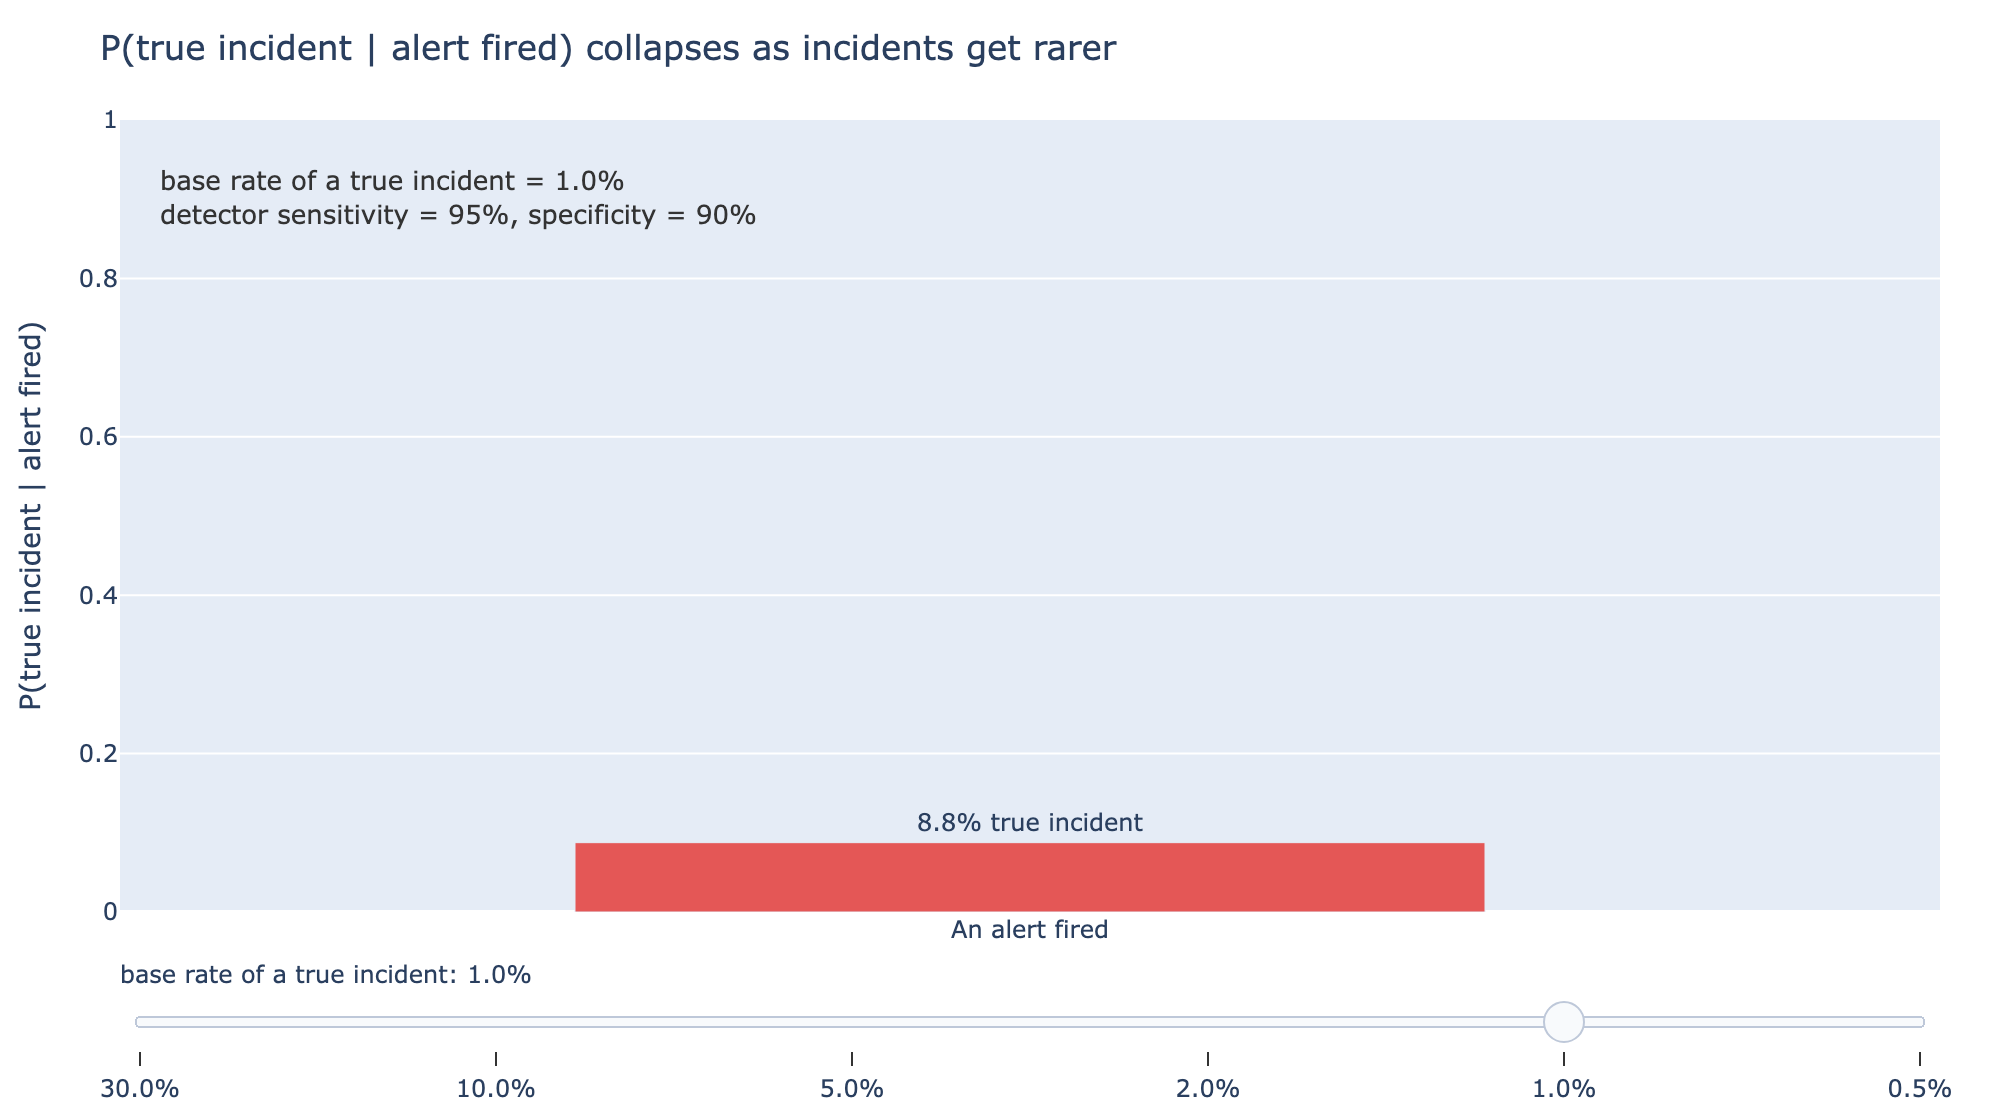

In [2]:
fig = FIGURES["chapter-03-fig-bayes-base-rate"]()
fig

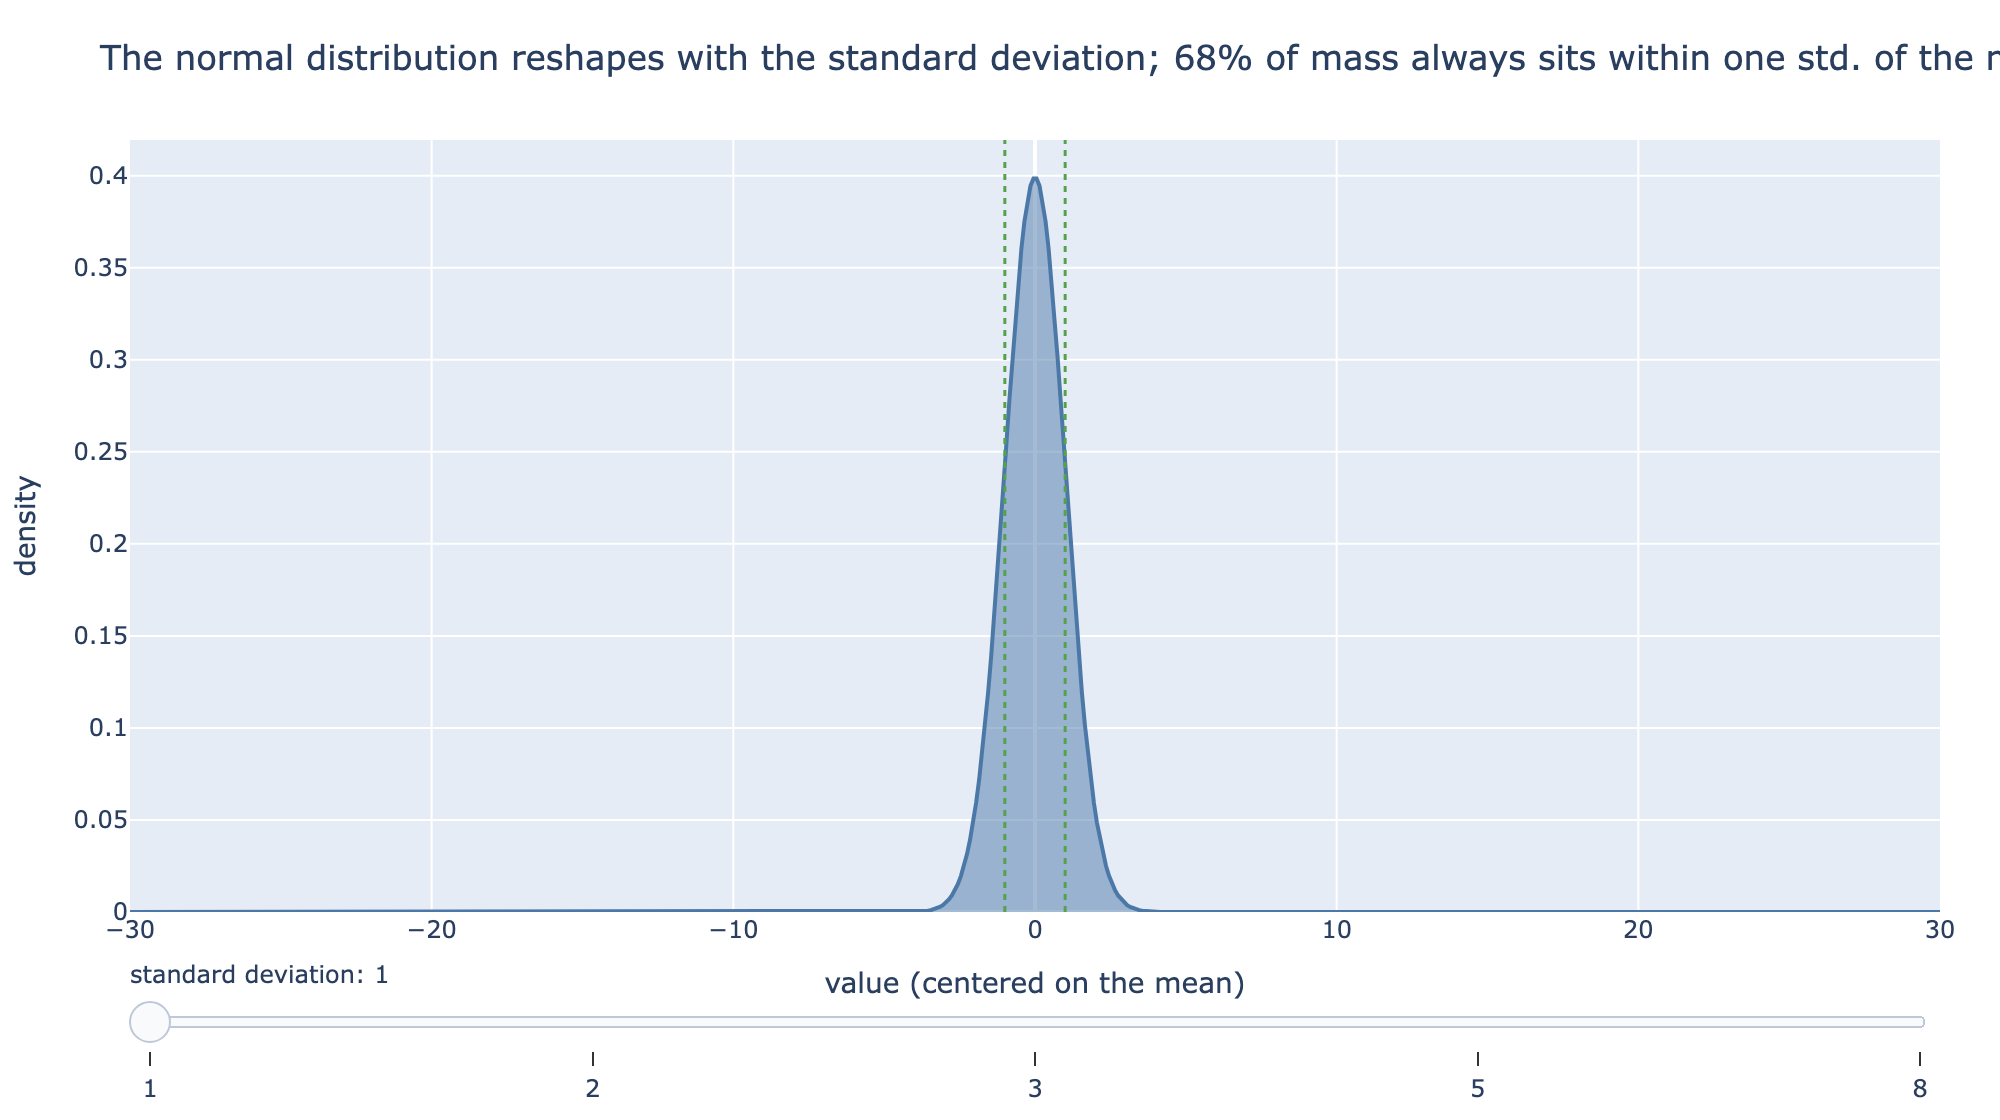

In [3]:
fig = FIGURES["chapter-03-fig-normal-empirical-rule"]()
fig

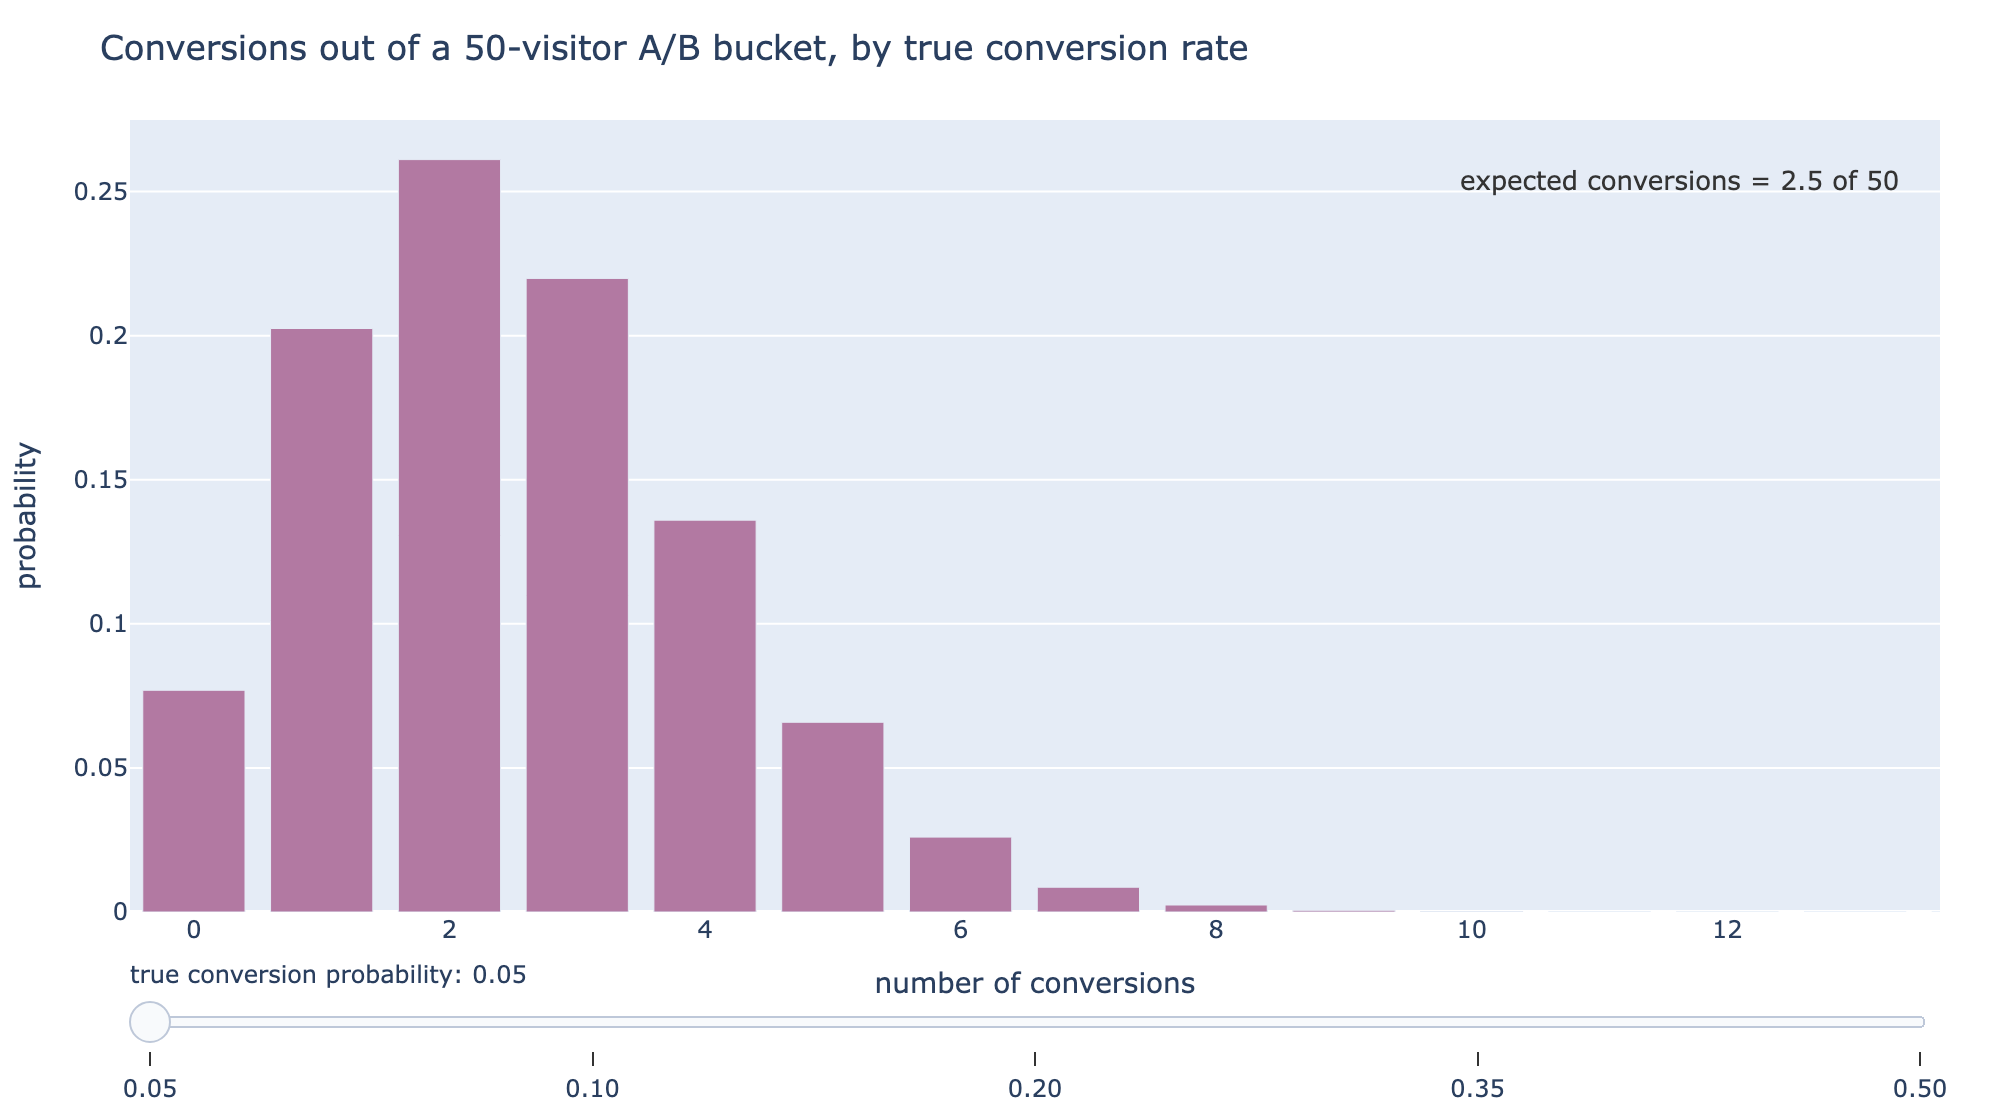

In [4]:
fig = FIGURES["chapter-03-fig-binomial-conversions"]()
fig

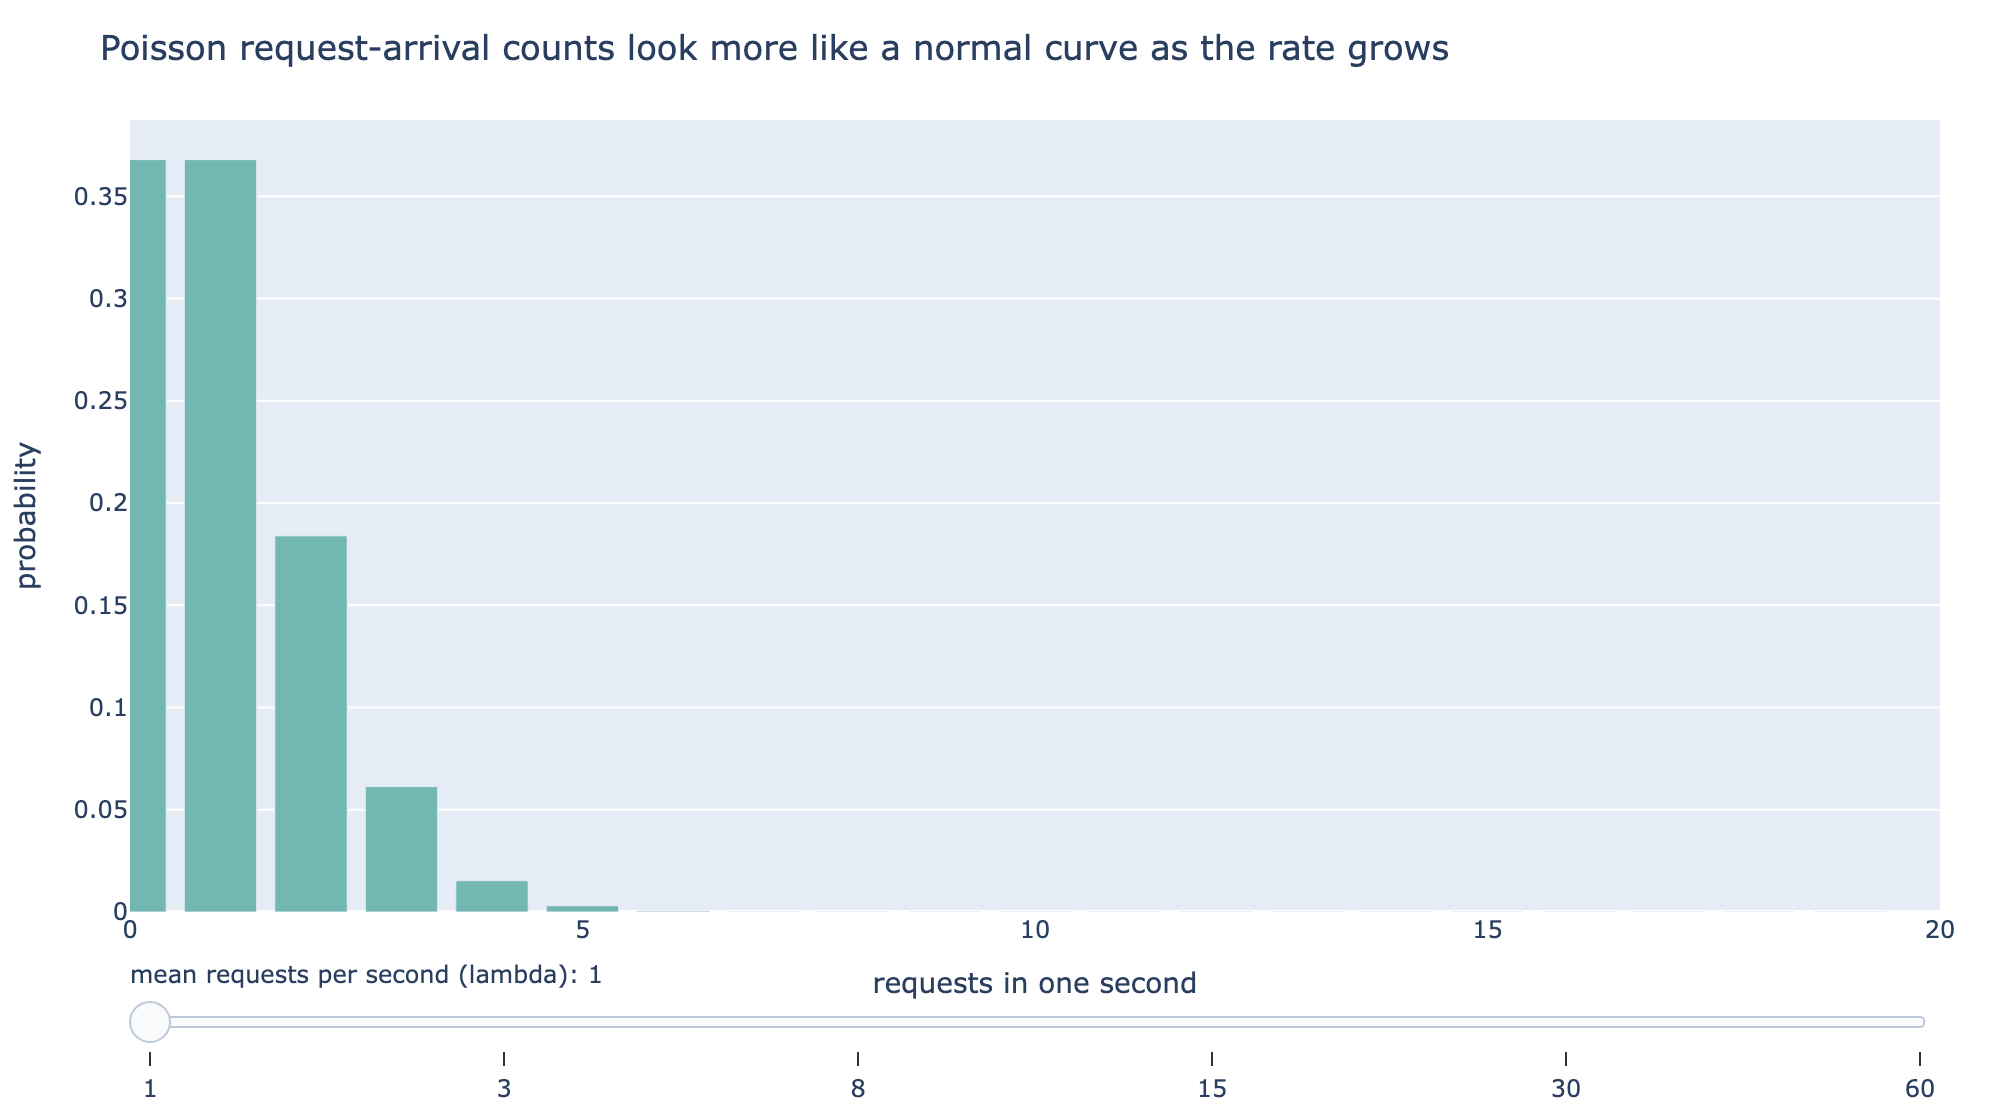

In [5]:
fig = FIGURES["chapter-03-fig-poisson-shape"]()
fig

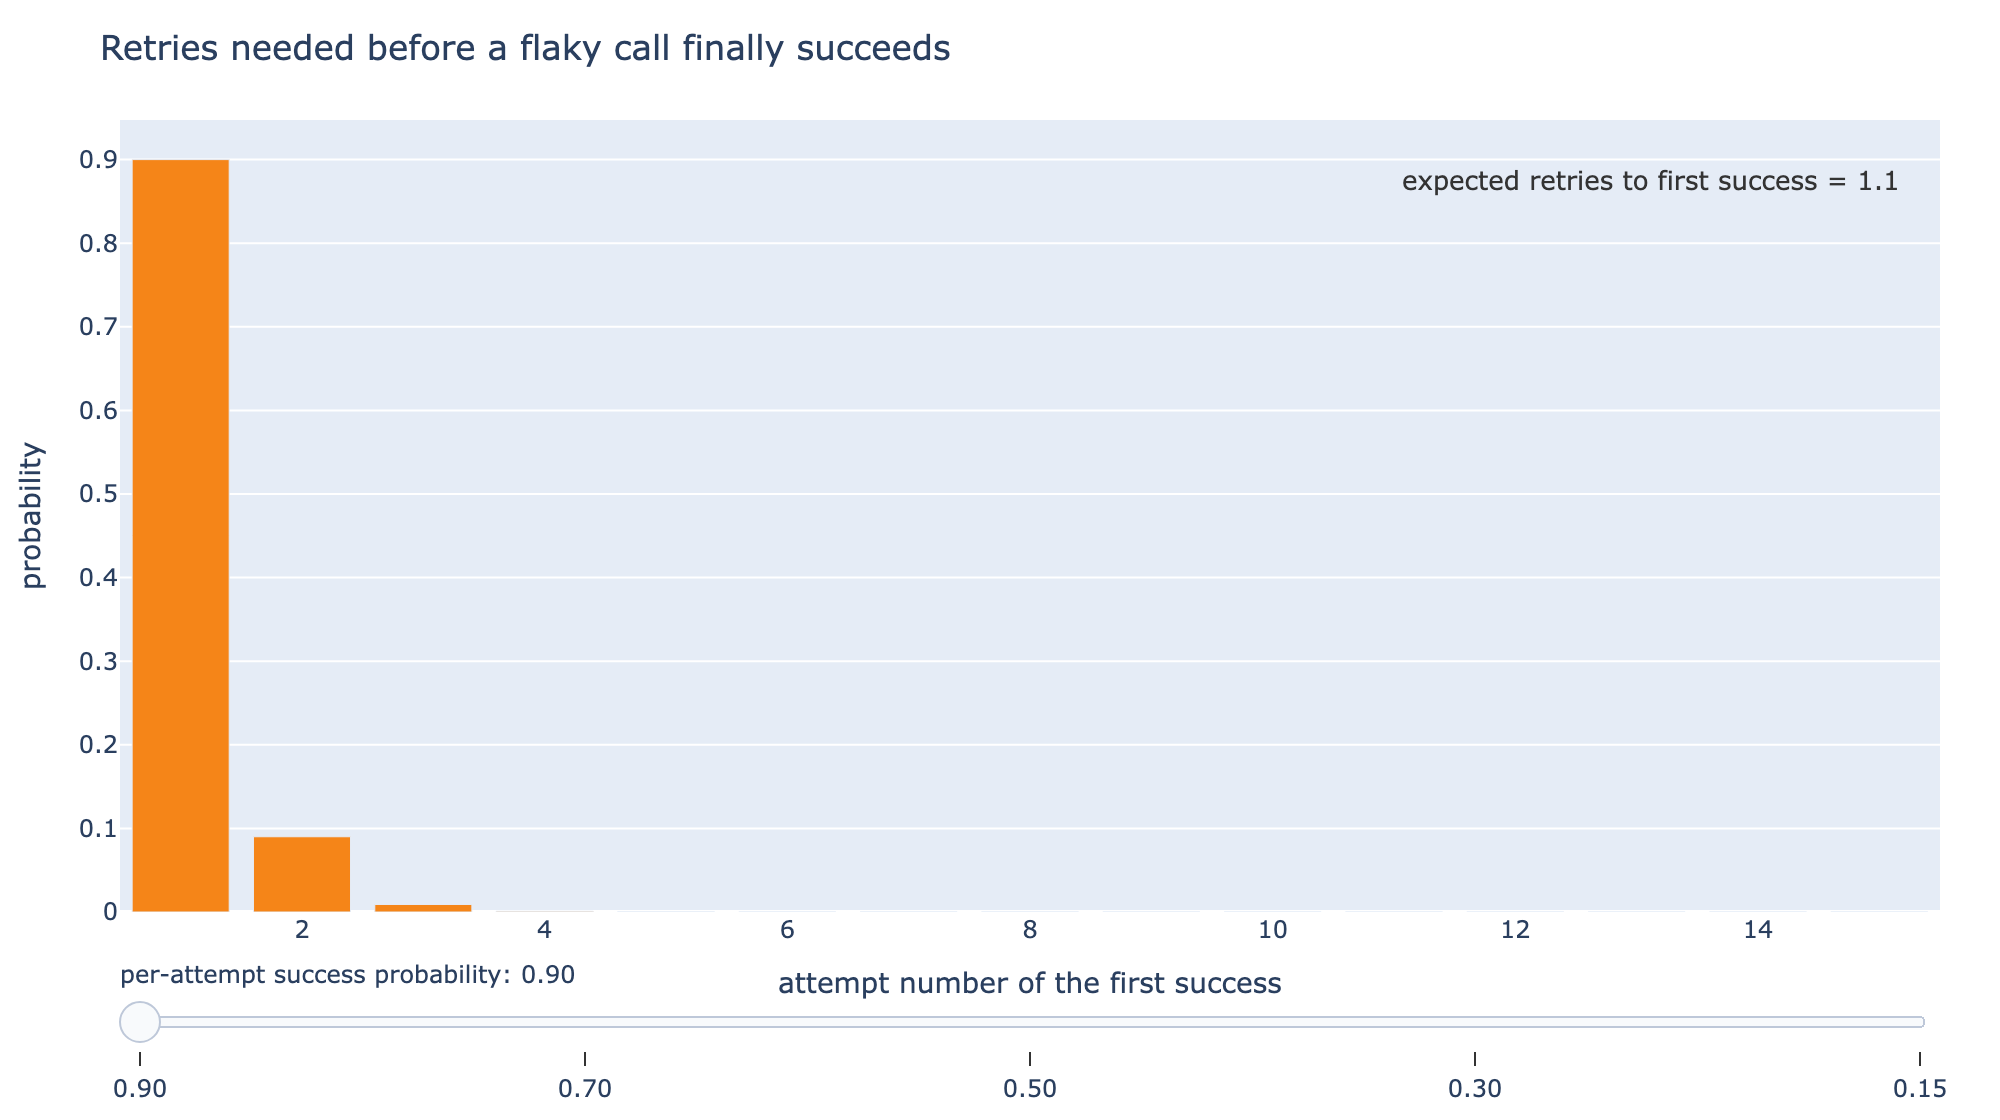

In [6]:
fig = FIGURES["chapter-03-fig-geometric-retries"]()
fig

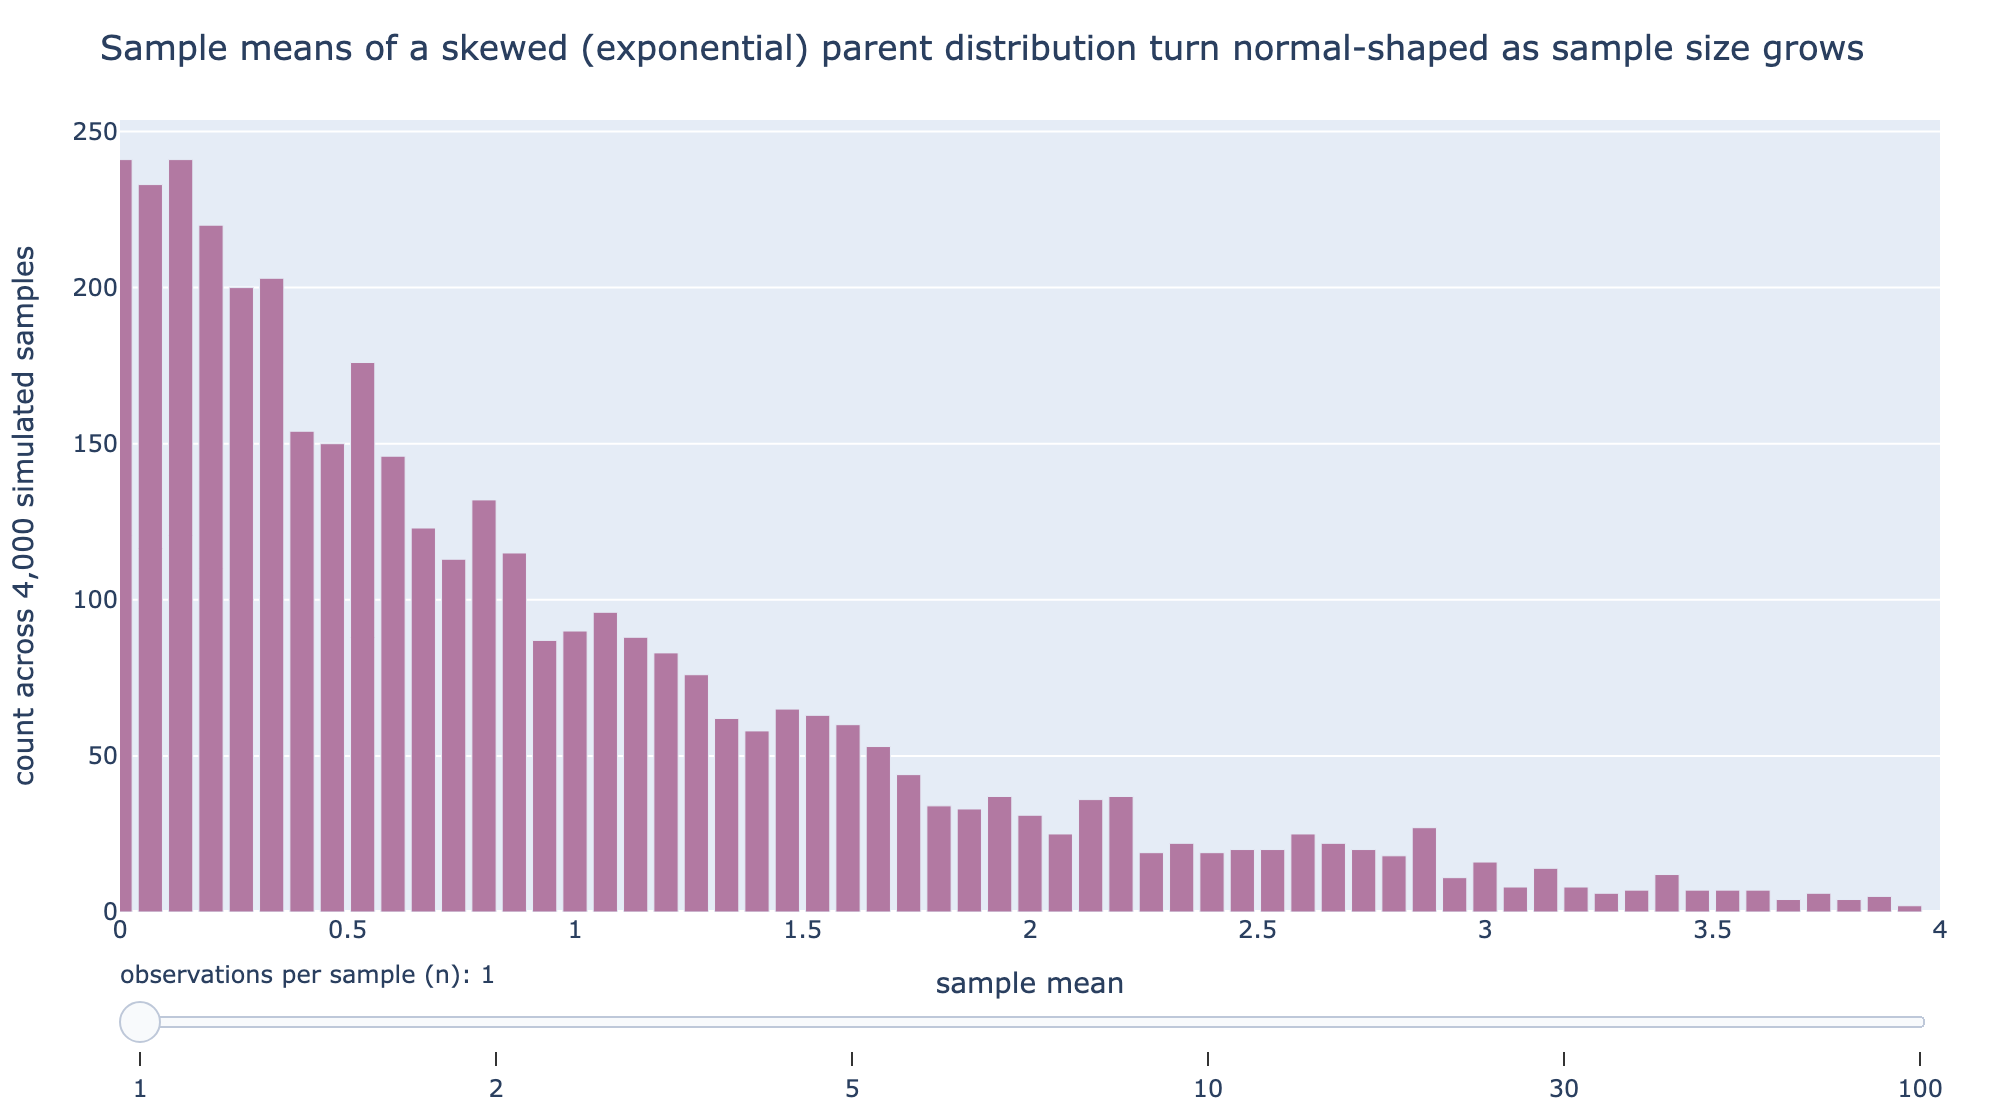

In [7]:
fig = FIGURES["chapter-03-fig-clt-simulation"]()
fig

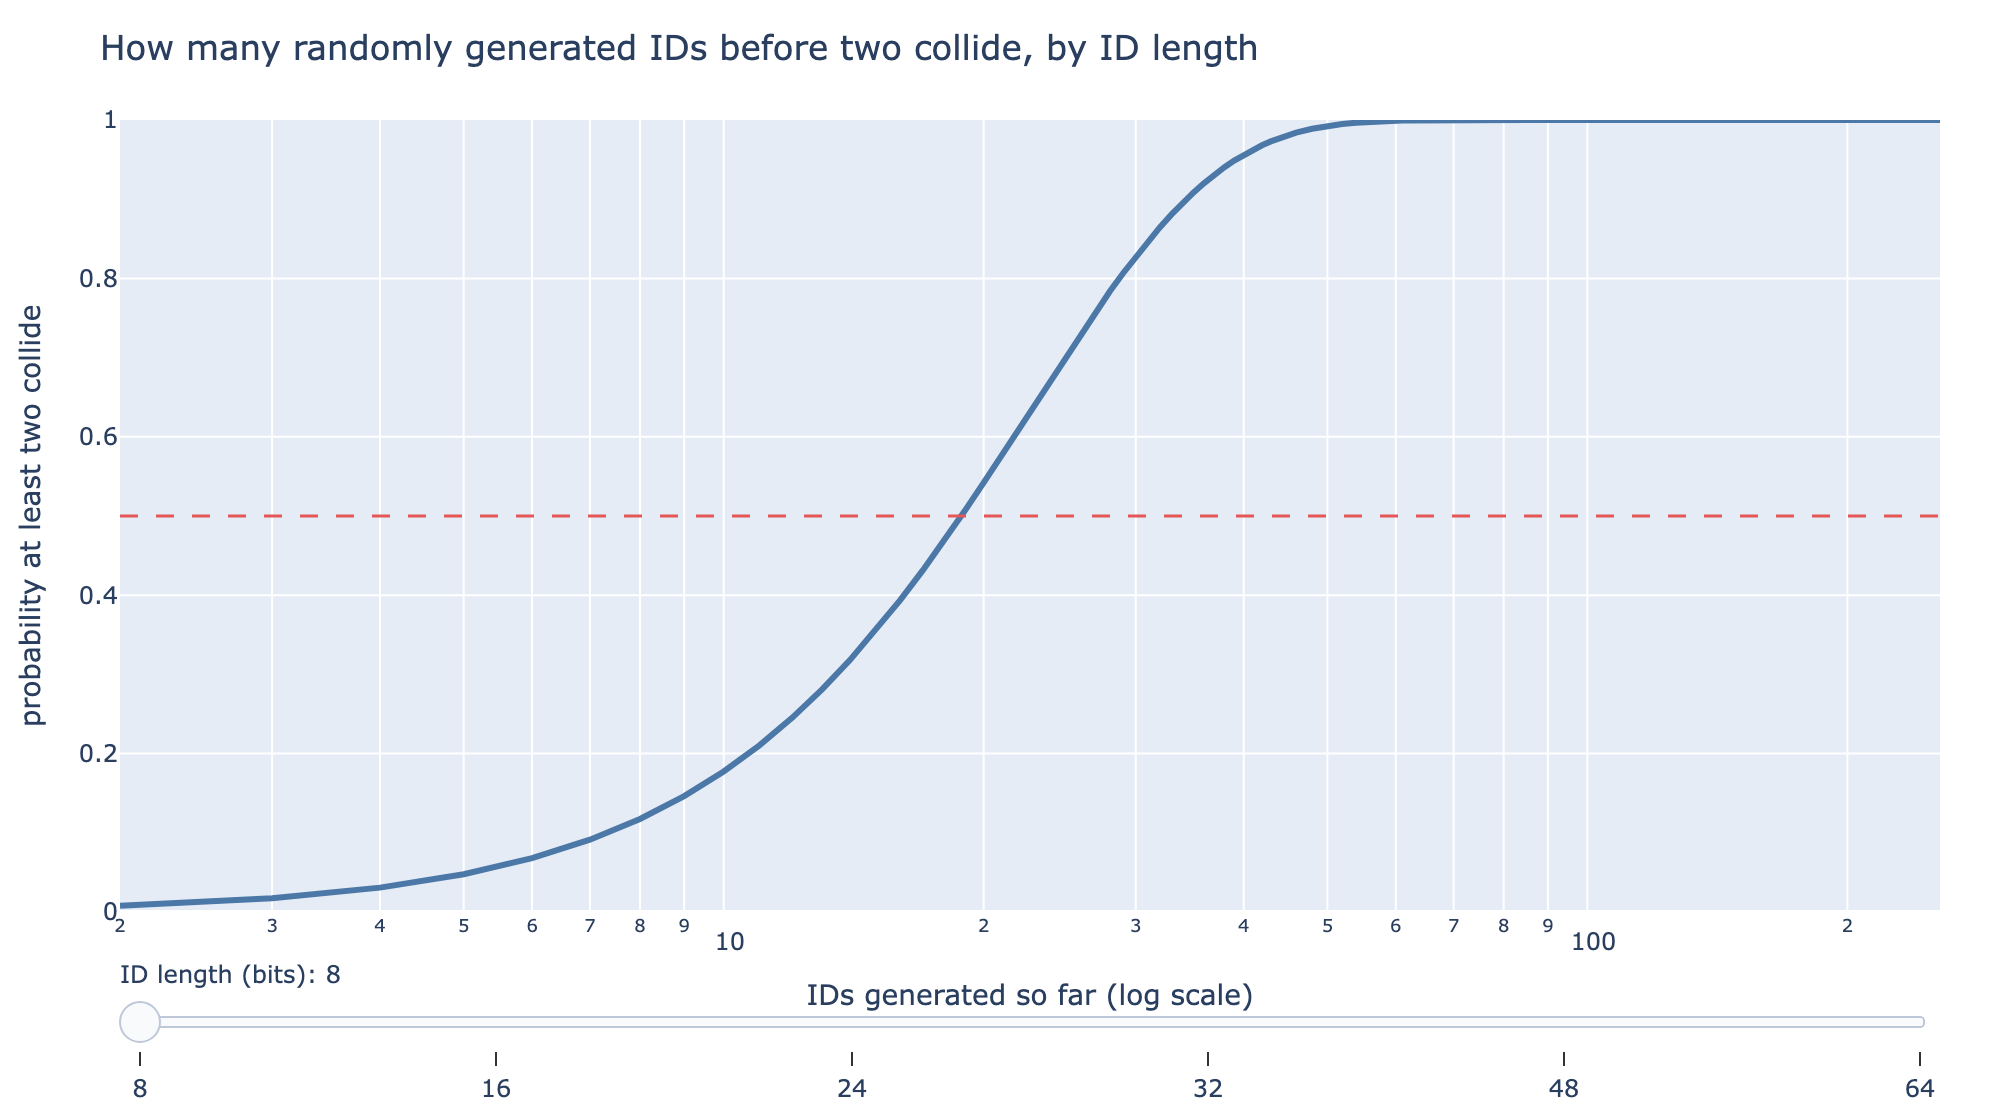

In [8]:
fig = FIGURES["chapter-03-fig-birthday-collision"]()
fig